In [1]:
import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[2])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)
from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import L1WaveletRecon
from custom_recons.created_app import TotalVariationRecon_Custom


## My files
import save_data_helpers
import recon_functions
import recon_plot_helpers
from gating_functions import golden_angle_coords_3d
import sigpy.plot as pl

### Load gated data

In [2]:
idx, resp_trimmed, data_bins, spoke_bins, index_bins = save_data_helpers.load_gate_outputs_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl')
print(f'data_bins[0].shape = {data_bins[0].shape}')
print(f'spoke_bins[0].shape = {spoke_bins[0].shape}')

ksp_gate0 = data_bins[0]
coords_gate0 = spoke_bins[0]
ncoils, npts, nsamples = data_bins[0].shape
img_shape = (58, nsamples, nsamples)
print(f'img_shape = {img_shape}')

espirit_mps_gate0 = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/coils/subject2_mid0082/espirit_mps_full_res_ksp_512_ungated.pkl')
print(f'espirit_mps_gate0.shape = {espirit_mps_gate0.shape}')

dcf_ksp_5gates = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/recons/subject2_mid0082/pkl_files_512/dcf_ksp_dense_512_5gates.pkl')
dcf_ksp_gate0 = dcf_ksp_5gates[0]
print(f'dcf_ksp_gate0.shape = {dcf_ksp_gate0.shape}')

ksp_gate0_with_dcf = ksp_gate0 * dcf_ksp_gate0[None,...]
print(f'ksp_gate0_with_dcf.shape = {ksp_gate0_with_dcf.shape}')

Loaded /home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl
  idx shape: (113116,)
  signal_trimmed shape: (113116,)
  data_bins: 5 elements
  spoke_bins: 5 elements
  index_bins: 5 elements
data_bins[0].shape = (15, 22623, 512)
spoke_bins[0].shape = (22623, 512, 3)
img_shape = (58, 512, 512)
espirit_mps_gate0.shape = (15, 58, 512, 512)
dcf_ksp_gate0.shape = (22623, 512)
ksp_gate0_with_dcf.shape = (15, 22623, 512)


### Select only certain coils for reconstruction

In [3]:
coils_select = [1, 8, 9, 10, 13]
ksp_coil_select = [ksp_gate0_with_dcf[i] for i in coils_select]
ksp_coil_select = np.stack(ksp_coil_select, axis=0)
print(f'ksp_coil_select.shape = {ksp_coil_select.shape}')


mps_coil_select = [espirit_mps_gate0[i] for i in coils_select]
mps_coil_select = np.stack(mps_coil_select, axis=0)
print(f'mps_coil_select.shape = {mps_coil_select.shape}')

ksp_coil_select.shape = (5, 22623, 512)
mps_coil_select.shape = (5, 58, 512, 512)


### Create operators on GPU

In [4]:
device= 1
ksp = ksp_coil_select.astype(np.complex64)
mps = mps_coil_select

ncoils, nz, ny, nx = mps.shape
print(f'ncoils = {ncoils}')

ksp = sp.to_device(ksp, device)
mps = sp.to_device(mps, device)
coords = sp.to_device(coords_gate0, device)

img_shape = mps.shape[1:]

with sp.Device(device):
    S = sp.linop.Multiply(img_shape, mps)
    F = sp.linop.NUFFT(mps.shape, coord=coords)
    A_sense = F * S

    ## Get k-space from applying normalization and then returning
    ## Apply NUFFT and regularize from [0,1]
    nufft_res = F.H * ksp
    xp = sp.Device(device).xp
    nufft_res_norm = xp.zeros_like(nufft_res)
    for coil in range(nufft_res_norm.shape[0]):
        img = xp.abs(nufft_res[coil])
        nufft_res_norm[coil] = (img - xp.min(img)) / (xp.max(img) - xp.min(img))
        del img
    
    del nufft_res


    ## Apply Sense and regularize from [0,1]
    nufft_sense = S.H * nufft_res_norm
    img = xp.abs(nufft_sense)
    nufft_sense_norm =  (img - xp.min(img)) / (xp.max(img) - xp.min(img))
    del nufft_sense
    del img

    ## Get normalized k-space
    ksp_norm = A_sense * nufft_sense_norm
    ksp_norm = ksp_norm.astype(xp.complex64)
    x = xp.copy(nufft_sense_norm).astype(ksp_norm.dtype)
    G = sp.linop.FiniteDifference(S.ishape)

ncoils = 5


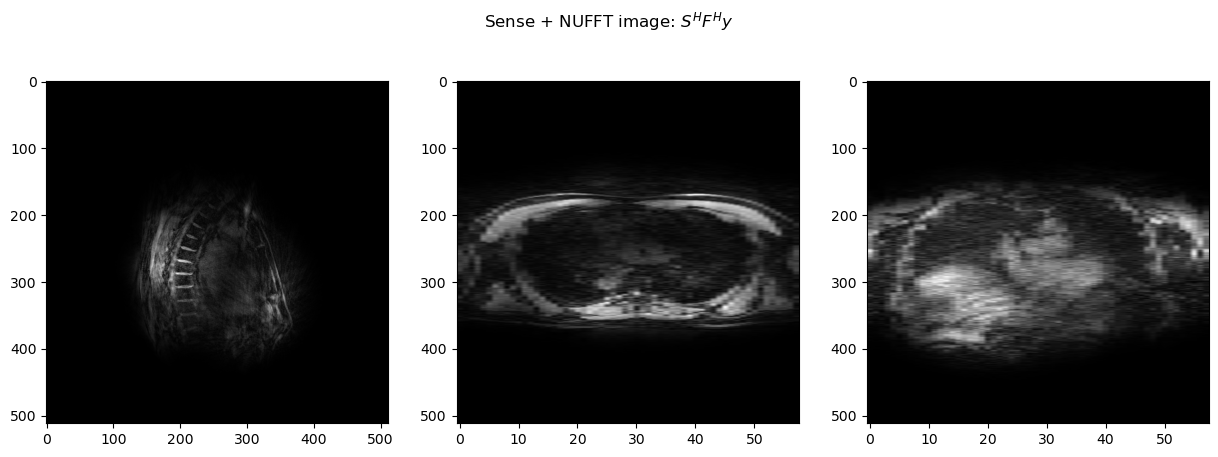

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [5]:
og_recon = nufft_sense_norm
recon_plot_helpers.plot_recons_all_axes(cp.asnumpy(x), title=rf'Sense + NUFFT image: $S^H F^H y$')

In [7]:
max_eig = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/recons/subject2_mid0082/max_eig_30iters_mid0082.pkl')
tau = sp.to_device((1/max_eig), device)

In [8]:
max_iter = 30
alpha = 1
lam = 1e-2
with sp.Device(device):
    xp = sp.Device(device).xp
    proxg = sp.prox.L1Reg(G.oshape, lamda=lam)

    
    ## PDHG initialization stuff
    A_trial = sp.linop.Vstack([A_sense, G])
    proxf1c = sp.prox.L2Reg(shape=ksp_norm.shape, lamda=1, y=-ksp_norm)
    proxf2c = sp.prox.Conj(proxg)
    proxfc = sp.prox.Stack([proxf1c, proxf2c])
    proxg = sp.prox.NoOp(x.shape)
    gamma_dual = 0
    gamma_primal =0
    sigma = 1

    u_trial = cp.zeros(A_trial.oshape, dtype=ksp_norm.dtype)
    S = sp.linop.Multiply(A_trial.oshape, sigma)
    AHA = A_trial.H * S * A_trial
    # max_eig = sp.app.MaxEig(
    #                 AHA,
    #                 dtype=x.dtype,
    #                 max_iter=max_iter,
    #                 show_pbar=True,
    #             ).run()

    # tau = 1/max_eig

In [9]:
with sp.Device(device):

    alg = sp.alg.PrimalDualHybridGradient(
                proxfc,
                proxg,
                A_trial,
                A_trial.H,
                x,
                u_trial,
                tau,
                sigma,
                gamma_primal=gamma_primal,
                gamma_dual=gamma_dual,
                max_iter=10,
            )

    while not alg.done():
        alg.update()
        print('\rTotalVariation, Iteration={}'.format(alg.iter), end='')

result = alg.x
# save_data_helpers.write_pickle(result, 'TV_2iters_try1.pkl')
print('PDHG Finished running.')

TotalVariation, Iteration=10PDHG Finished running.


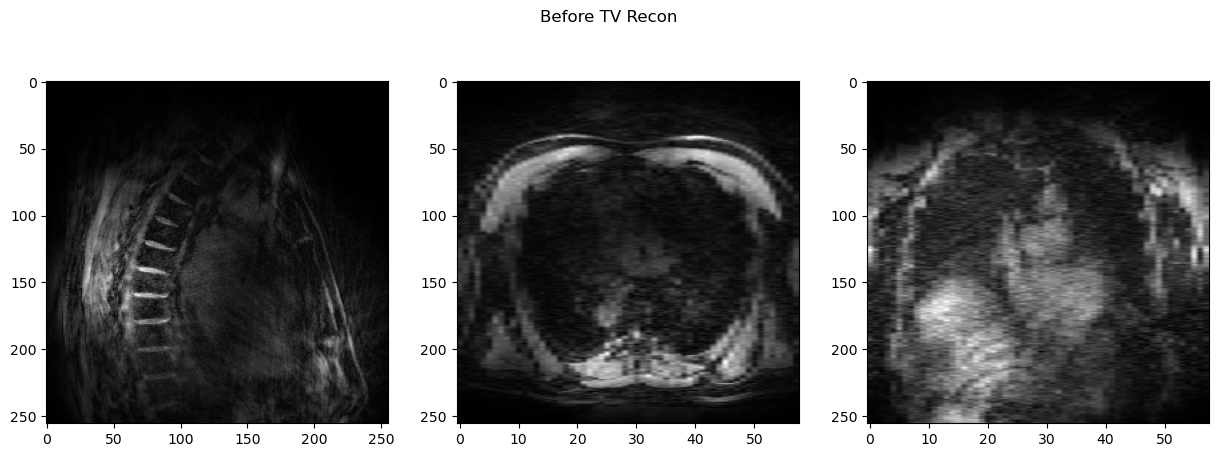

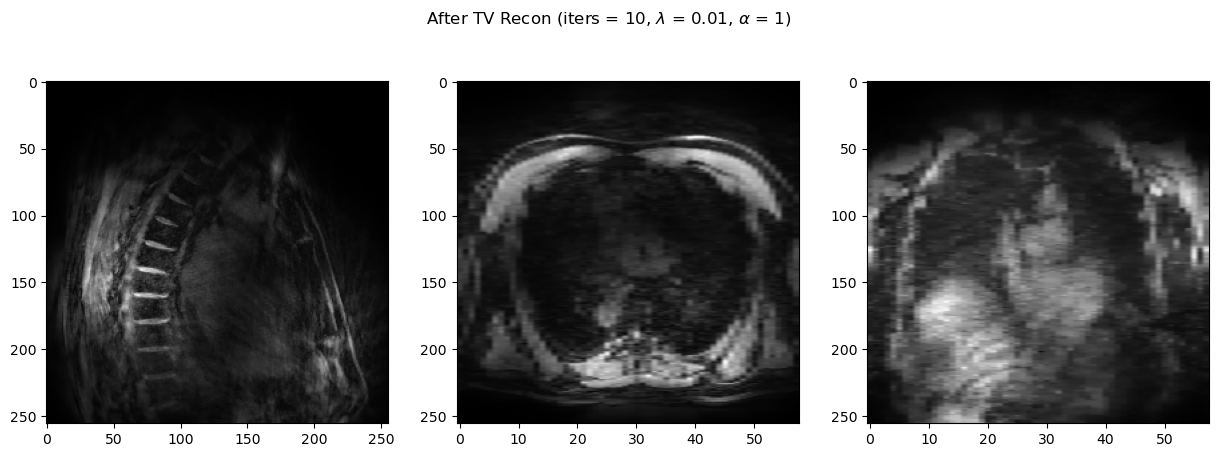

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [10]:
oshape=(58, 256, 256)
# Crop along the last two dimensions
og_cropped = recon_plot_helpers.crop_xy_dimension(nufft_sense_norm, oshape=oshape)
recon_cropped = recon_plot_helpers.crop_xy_dimension(result, oshape=oshape)


recon_plot_helpers.plot_recons_all_axes(cp.asnumpy(og_cropped), title=f'Before TV Recon')
recon_plot_helpers.plot_recons_all_axes(cp.asnumpy(recon_cropped), title=rf'After TV Recon (iters = {alg.iter}, $\lambda$ = {lam}, $\alpha$ = {alpha})')

### Try using assembled App

In [15]:
print(ksp_coil_select.shape)
print(coords_gate0.shape)
print(espirit_mps_gate0.shape)

(5, 22623, 512)
(22623, 512, 3)
(15, 58, 512, 512)


In [16]:
result_app = TotalVariationRecon_Custom(y=ksp_coil_select,
                                        mps=mps_coil_select,
                                        lamda=1e-2,
                                        coord=coords_gate0, device=0).run()

MaxEig:   0%|          | 0/30 [00:00<?, ?it/s]

TotalVariationRecon_Custom:   0%|          | 0/100 [00:00<?, ?it/s]

In [17]:
print(result_app.shape)

(58, 512, 512)


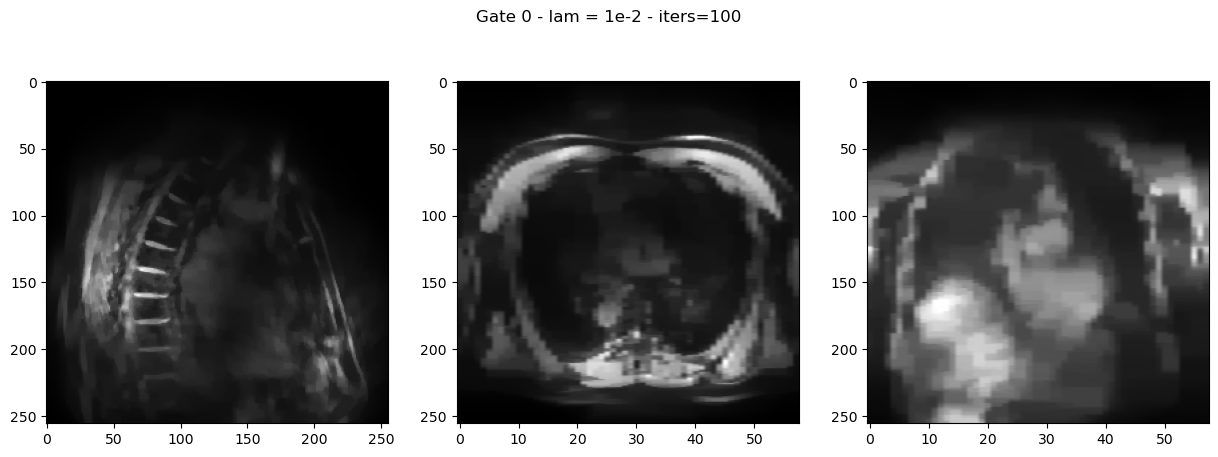

In [21]:
result_app_cropped = recon_plot_helpers.crop_xy_dimension(result_app, oshape=(58, 256, 256))
fig, axs = recon_plot_helpers.plot_recons_all_axes(np.abs(cp.asnumpy(result_app_cropped)), title=f'Gate 0 - lam = 1e-2 - iters=100')